#Assignment 7 :GAN



In [34]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

LATENT_DIM = 128
IMG_SHAPE = (32, 32, 3)
TARGET_CLASS = 5
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
print(f"Target class: {TARGET_CLASS} → {CLASS_NAMES[TARGET_CLASS]}")

TensorFlow: 2.19.0
GPU available: True
Target class: 5 → dog


Training images (dog): 5000
Test images     (dog): 1000


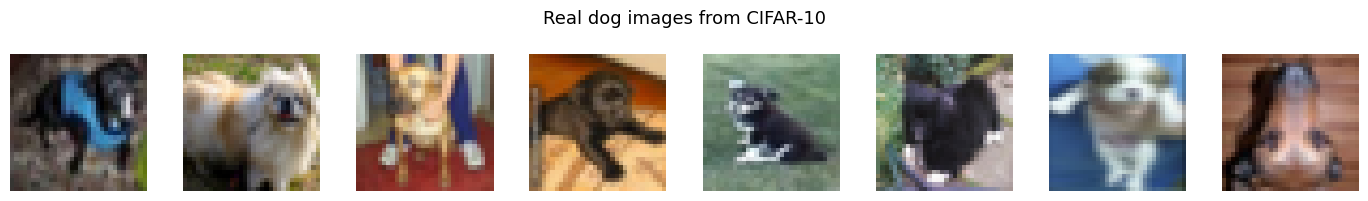

In [21]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = (
    keras.datasets.cifar10.load_data()
)

# keep only dog images
mask_train = (y_train_full.squeeze() == TARGET_CLASS)
mask_test = (y_test_full.squeeze() == TARGET_CLASS)

x_train = x_train_full[mask_train].astype("float32")
x_test = x_test_full[mask_test].astype("float32")

# scale pixels from [0, 255] to [-1, 1]
x_train = (x_train - 127.5) / 127.5
x_test = (x_test - 127.5) / 127.5

print(f"Training images ({CLASS_NAMES[TARGET_CLASS]}): {x_train.shape[0]}")
print(f"Test images     ({CLASS_NAMES[TARGET_CLASS]}): {x_test.shape[0]}")

# show some real dog images
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i] * 0.5 + 0.5)  # rescale back to [0,1] for display
    ax.axis("off")
fig.suptitle(f"Real {CLASS_NAMES[TARGET_CLASS]} images from CIFAR-10", fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
def build_generator(latent_dim=LATENT_DIM):
    z = keras.Input(shape=(latent_dim,), name="z_input")

    # project noise vector to a small 4×4 feature map
    x = layers.Dense(4 * 4 * 256, use_bias=False)(z)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Reshape((4, 4, 256))(x)

    # up-conv block 1: 4×4 → 8×8
    x = layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # up-conv block 2: 8×8 → 16×16
    x = layers.Conv2DTranspose(64, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # up-conv block 3: 16×16 → 32×32 (final image)
    x = layers.Conv2DTranspose(3, 4, strides=2, padding="same", use_bias=False,
                               activation="tanh")(x)

    model = keras.Model(z, x, name="generator")
    return model

generator = build_generator()
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_input (InputLayer)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4096)           │       524,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 8, 8, 128)      │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 16, 16, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 32, 32, 3)      │         3,072 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,872 (4.58 MB)

 Trainable params: 1,191,296 (4.54 MB)

 Non-trainable params: 8,576 (33.50 KB)

In [23]:
def build_discriminator():
    img = keras.Input(shape=IMG_SHAPE, name="image")

    # conv block 1: 32×32 → 16×16
    x = layers.Conv2D(64, 4, strides=2, padding="same")(img)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    # conv block 2: 16×16 → 8×8
    x = layers.Conv2D(128, 4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    # conv block 3: 8×8 → 4×4
    x = layers.Conv2D(256, 4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(1)(x)  # single logit: real or fake

    model = keras.Model(img, x, name="discriminator")
    return model

discriminator = build_discriminator()
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 662,977 (2.53 MB)

 Trainable params: 662,977 (2.53 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
cross_entropy = keras.losses.BinaryCrossentropy(from_logits=True)

def disc_loss(real_out, fake_out):
    real_loss = cross_entropy(tf.ones_like(real_out), real_out)
    fake_loss = cross_entropy(tf.zeros_like(fake_out), fake_out)
    return real_loss + fake_loss

def gen_loss(fake_out):
    return cross_entropy(tf.ones_like(fake_out), fake_out)

gen_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)
disc_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)

print("Loss functions and optimizers ready.")

Loss functions and optimizers ready.


In [25]:
@tf.function
def train_step(real_images):
    batch = tf.shape(real_images)[0]
    noise = tf.random.normal([batch, LATENT_DIM])

    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        fake_images = generator(noise, training=True)

        real_out = discriminator(real_images, training=True)
        fake_out = discriminator(fake_images, training=True)

        g_loss = gen_loss(fake_out)
        d_loss = disc_loss(real_out, fake_out)

    g_grads = gt.gradient(g_loss, generator.trainable_variables)
    d_grads = dt.gradient(d_loss, discriminator.trainable_variables)

    gen_opt.apply_gradients(zip(g_grads, generator.trainable_variables))
    disc_opt.apply_gradients(zip(d_grads, discriminator.trainable_variables))

    return g_loss, d_loss

print("Training step function compiled.")

Training step function compiled.


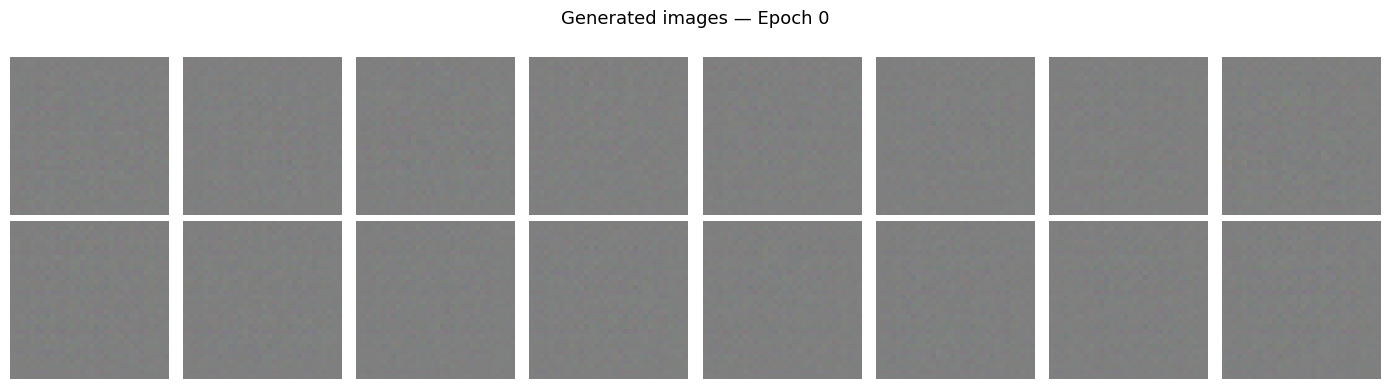

In [26]:
fixed_seed = tf.random.normal([16, LATENT_DIM], seed=SEED)

def show_generated(epoch, seed=fixed_seed):
    imgs = generator(seed, training=False).numpy()
    imgs = imgs * 0.5 + 0.5   # rescale [-1,1] → [0,1] for display
    imgs = np.clip(imgs, 0, 1)

    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(imgs[i])
        ax.axis("off")
    fig.suptitle(f"Generated images — Epoch {epoch}", fontsize=13)
    plt.tight_layout()
    plt.show()

# test it before training — should look like pure noise/garbage
show_generated(0)

Epoch   1  |  G loss 2.3837  |  D loss 0.1958


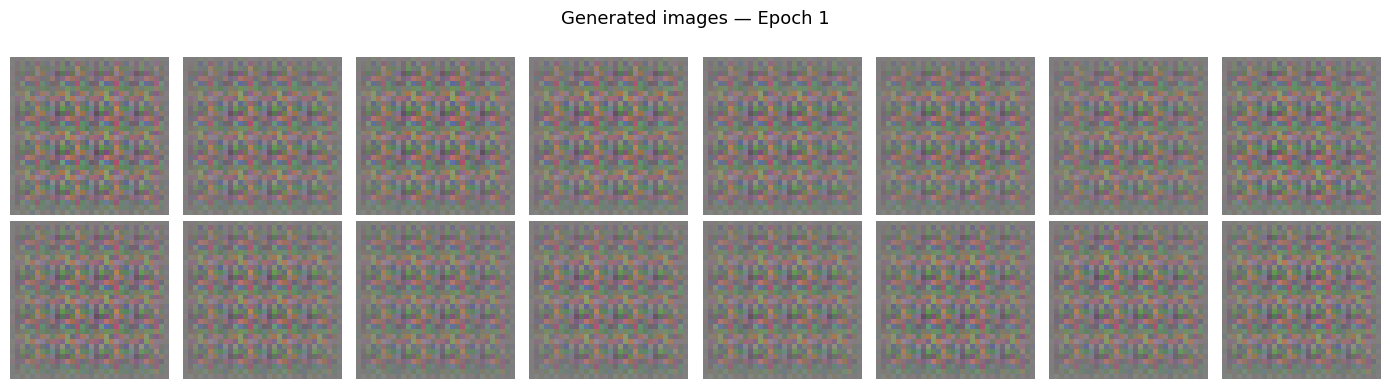

Epoch  10  |  G loss 2.0946  |  D loss 0.5323


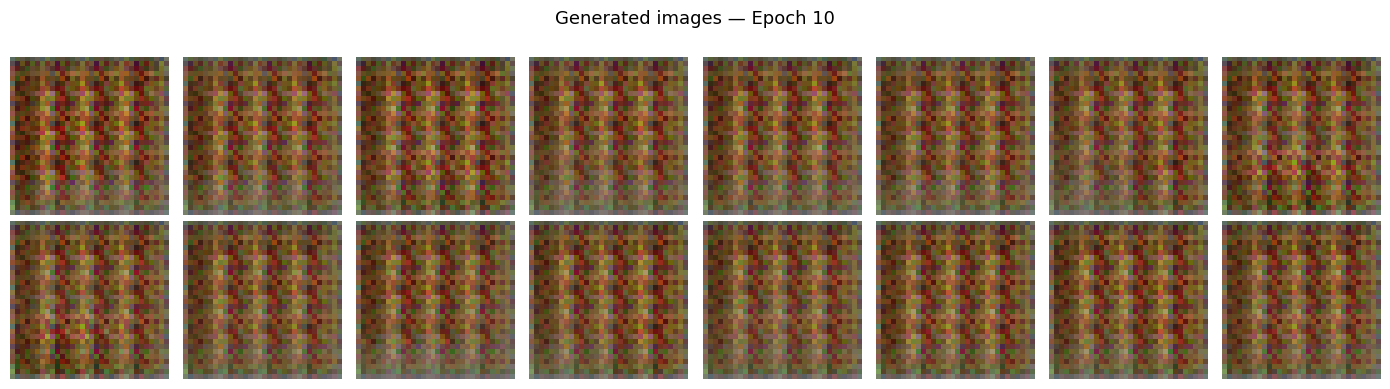

Epoch  20  |  G loss 1.0984  |  D loss 0.8930


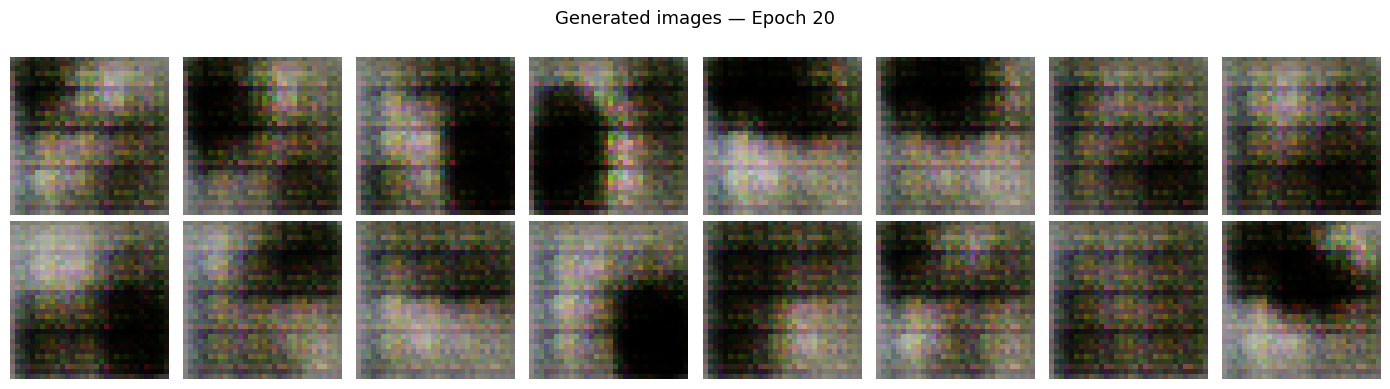

Epoch  30  |  G loss 1.4954  |  D loss 0.7494


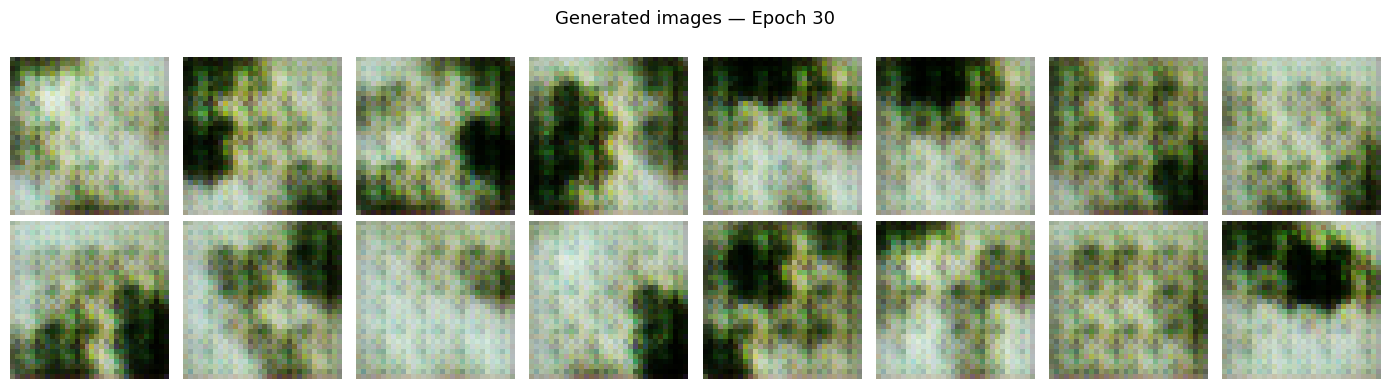

Epoch  40  |  G loss 1.3052  |  D loss 0.7934


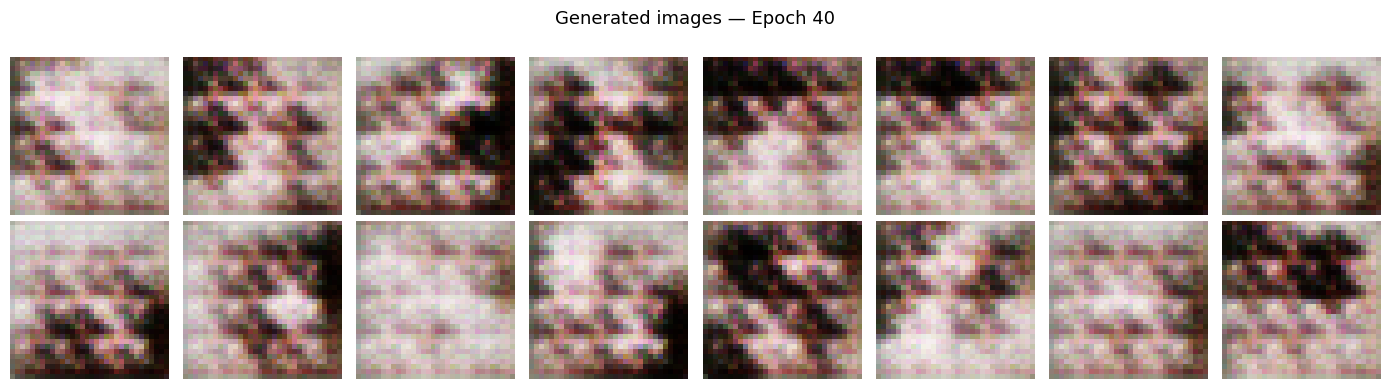

Epoch  50  |  G loss 1.1932  |  D loss 0.8767


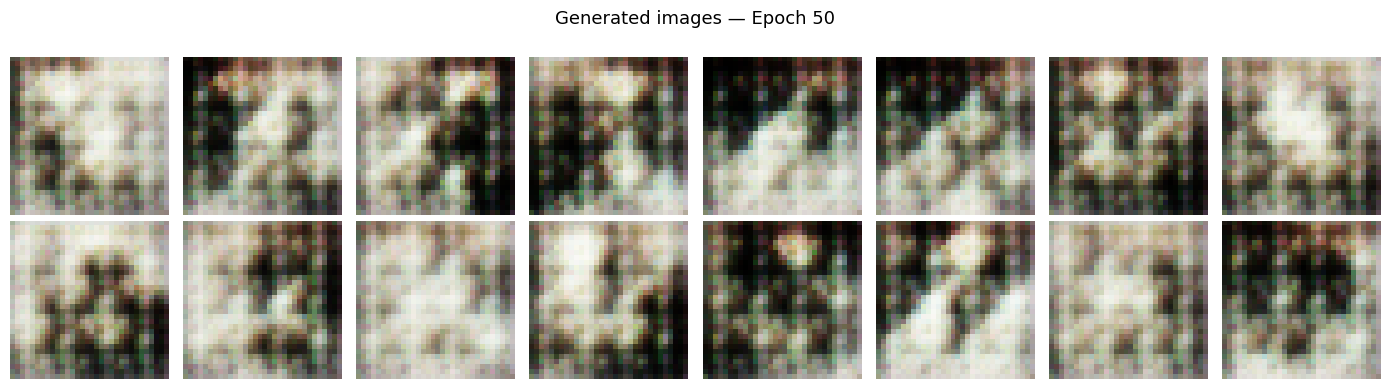

Epoch  60  |  G loss 1.6758  |  D loss 0.6285


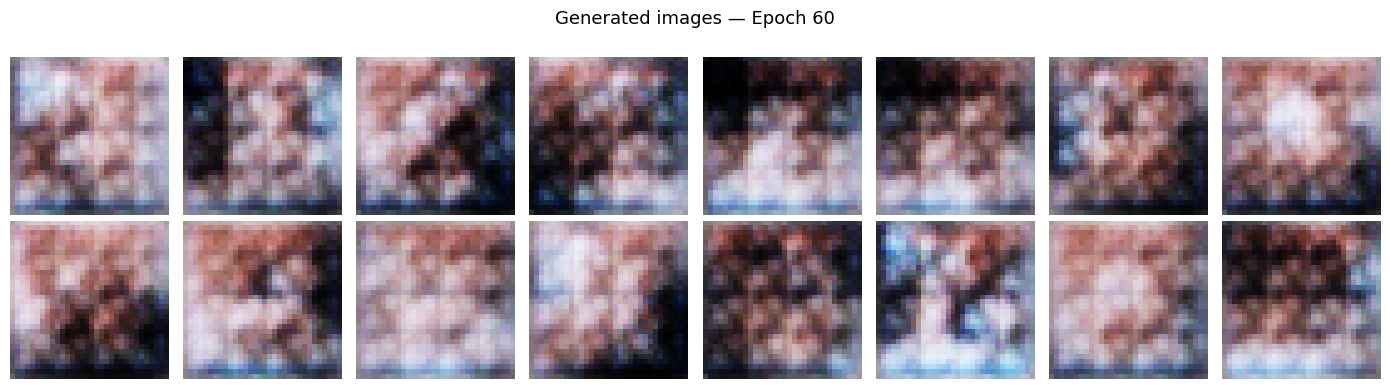

Epoch  70  |  G loss 0.9085  |  D loss 1.1337


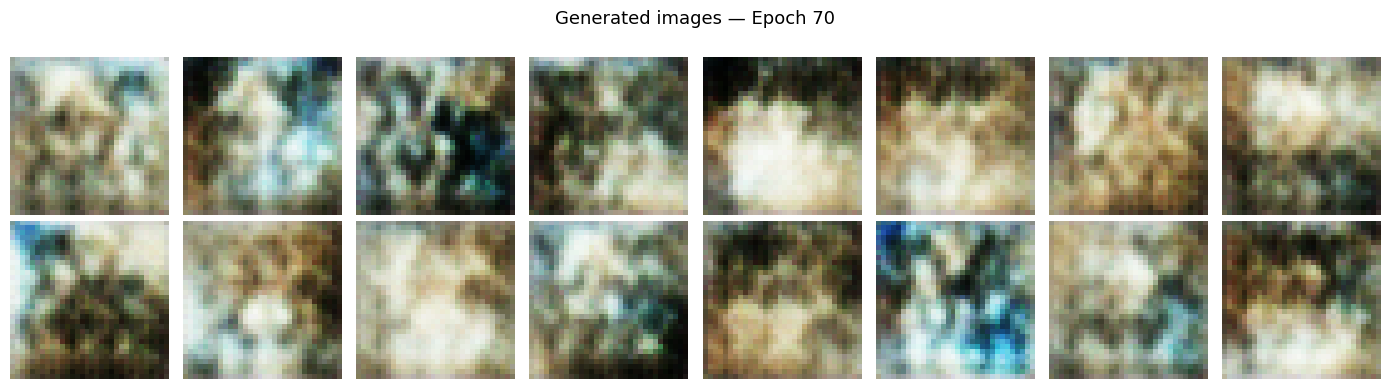

Epoch  80  |  G loss 1.5146  |  D loss 0.7058


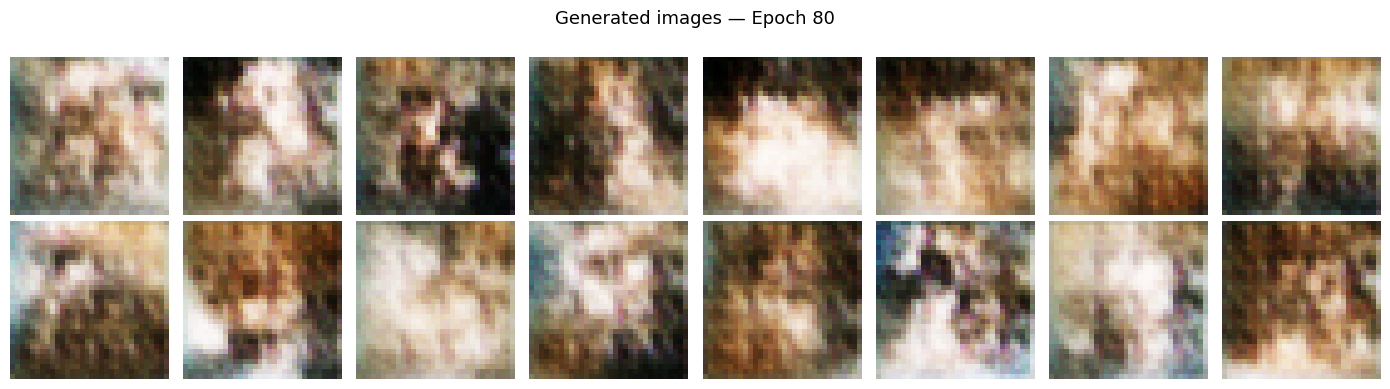

In [27]:
BATCH_SIZE = 128
EPOCHS = 80

dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(x_train.shape[0], seed=SEED)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

g_losses, d_losses = [], []

for epoch in range(1, EPOCHS + 1):
    for batch in dataset:
        gl, dl = train_step(batch)
    g_losses.append(float(gl))
    d_losses.append(float(dl))

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}  |  G loss {gl:.4f}  |  D loss {dl:.4f}")
        show_generated(epoch)

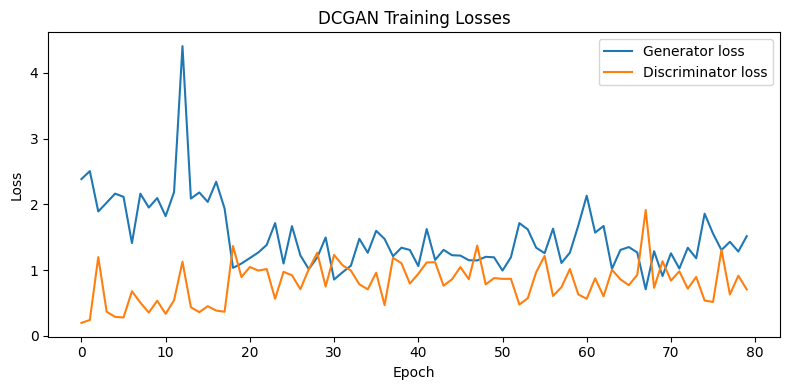

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(g_losses, label="Generator loss")
ax.plot(d_losses, label="Discriminator loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("DCGAN Training Losses")
ax.legend()
plt.tight_layout()
plt.show()

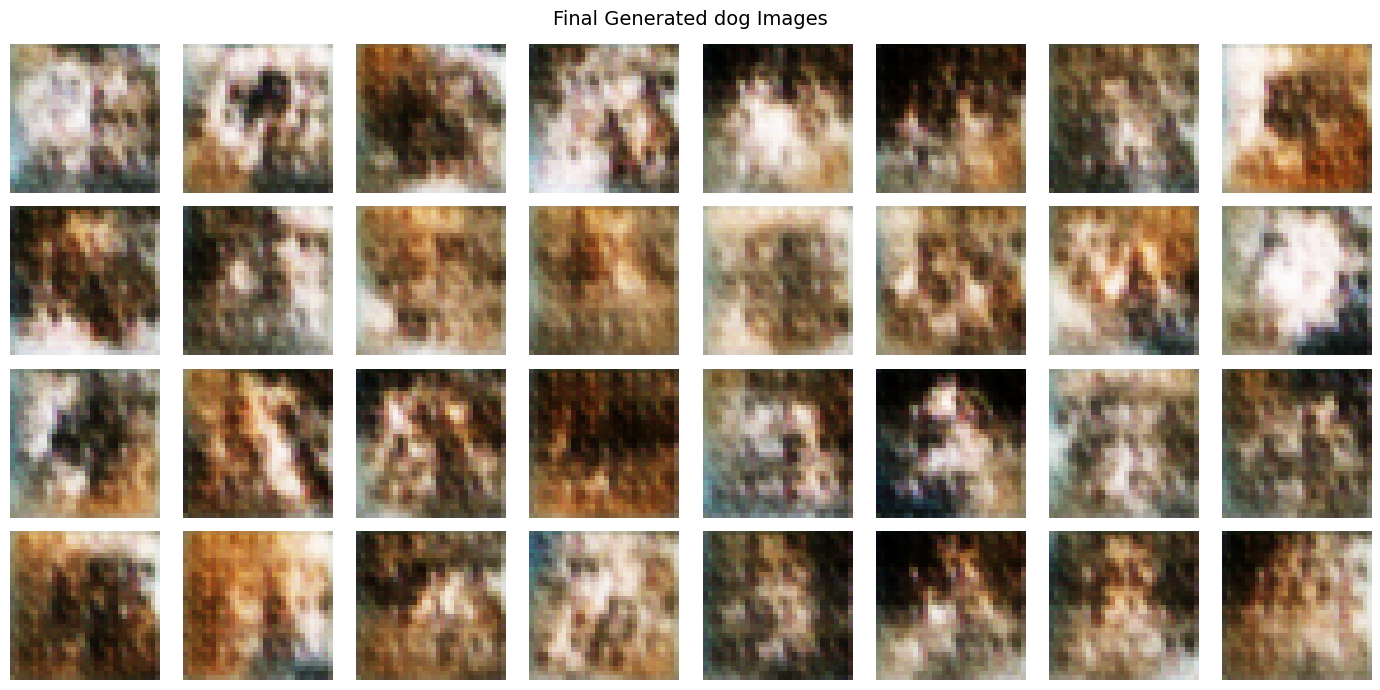

In [29]:
noise = tf.random.normal([32, LATENT_DIM])
final_imgs = generator(noise, training=False).numpy() * 0.5 + 0.5
final_imgs = np.clip(final_imgs, 0, 1)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(final_imgs[i])
    ax.axis("off")
fig.suptitle(f"Final Generated {CLASS_NAMES[TARGET_CLASS]} Images", fontsize=14)
plt.tight_layout()
plt.show()

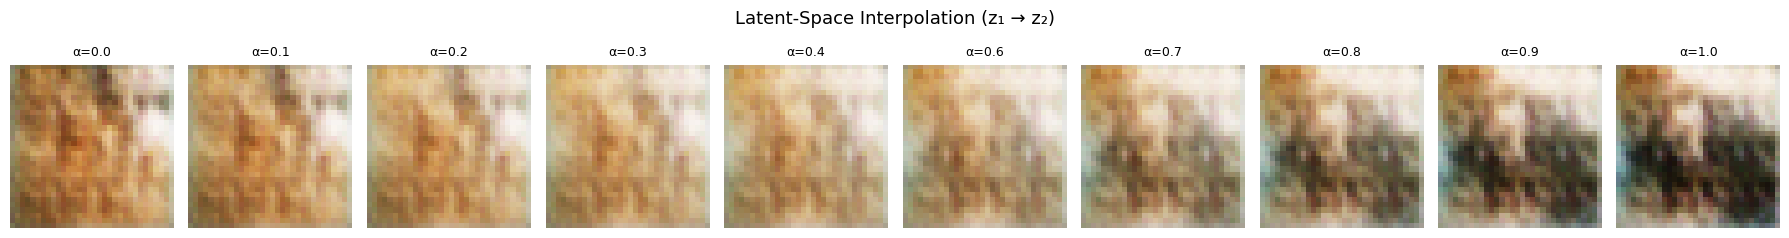

In [30]:
z1 = tf.random.normal([1, LATENT_DIM], seed=0)
z2 = tf.random.normal([1, LATENT_DIM], seed=99)

n_steps = 10
alphas = np.linspace(0, 1, n_steps)
interp_z = np.array([(1 - a) * z1.numpy() + a * z2.numpy() for a in alphas])
interp_z = interp_z.reshape(n_steps, LATENT_DIM)

interp_imgs = generator(interp_z, training=False).numpy() * 0.5 + 0.5
interp_imgs = np.clip(interp_imgs, 0, 1)

fig, axes = plt.subplots(1, n_steps, figsize=(18, 2.5))
for i, ax in enumerate(axes):
    ax.imshow(interp_imgs[i])
    ax.set_title(f"α={alphas[i]:.1f}", fontsize=9)
    ax.axis("off")
fig.suptitle("Latent-Space Interpolation (z₁ → z₂)", fontsize=13)
plt.tight_layout()
plt.show()

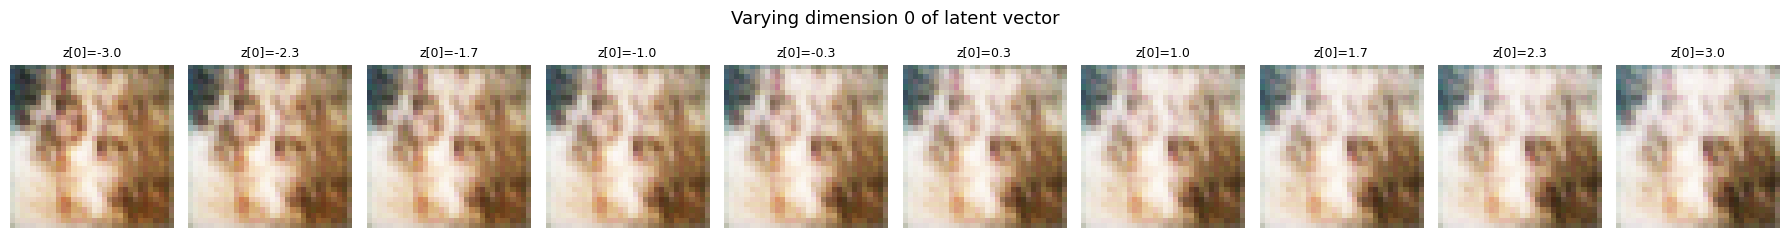

In [31]:
base_z = tf.random.normal([1, LATENT_DIM], seed=7).numpy()
dim_to_vary = 0
vals = np.linspace(-3, 3, 10)

sweep_z = np.tile(base_z, (len(vals), 1))
sweep_z[:, dim_to_vary] = vals

sweep_imgs = generator(sweep_z, training=False).numpy() * 0.5 + 0.5
sweep_imgs = np.clip(sweep_imgs, 0, 1)

fig, axes = plt.subplots(1, len(vals), figsize=(18, 2.5))
for i, ax in enumerate(axes):
    ax.imshow(sweep_imgs[i])
    ax.set_title(f"z[{dim_to_vary}]={vals[i]:.1f}", fontsize=9)
    ax.axis("off")
fig.suptitle(f"Varying dimension {dim_to_vary} of latent vector", fontsize=13)
plt.tight_layout()
plt.show()

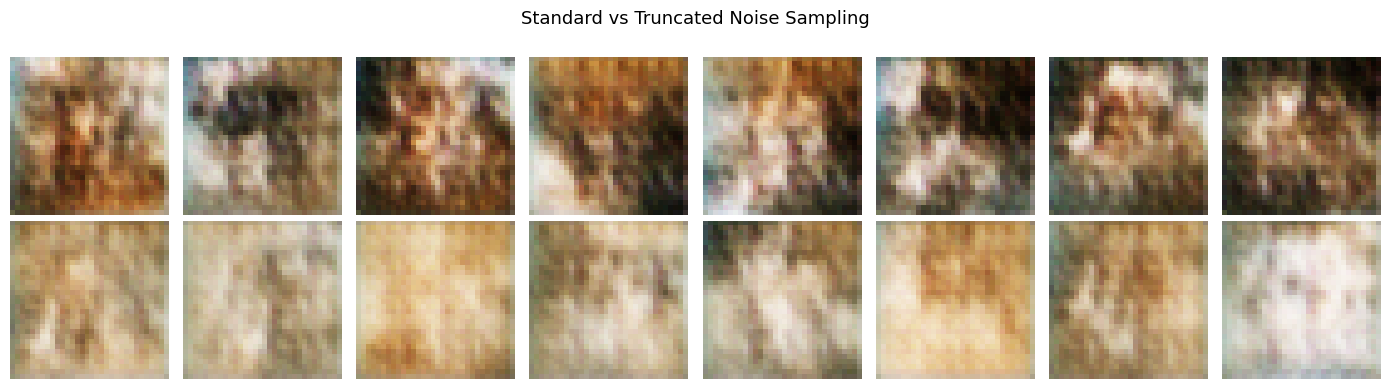

In [32]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))

z_normal = tf.random.normal([8, LATENT_DIM], seed=42)
z_truncated = tf.random.truncated_normal([8, LATENT_DIM], stddev=0.5, seed=42)

for i in range(8):
    img_n = generator(z_normal[i:i+1], training=False).numpy()[0] * 0.5 + 0.5
    img_t = generator(z_truncated[i:i+1], training=False).numpy()[0] * 0.5 + 0.5
    axes[0, i].imshow(np.clip(img_n, 0, 1))
    axes[0, i].axis("off")
    axes[1, i].imshow(np.clip(img_t, 0, 1))
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Normal z", fontsize=11)
axes[1, 0].set_ylabel("Truncated z", fontsize=11)
fig.suptitle("Standard vs Truncated Noise Sampling", fontsize=13)
plt.tight_layout()
plt.show()


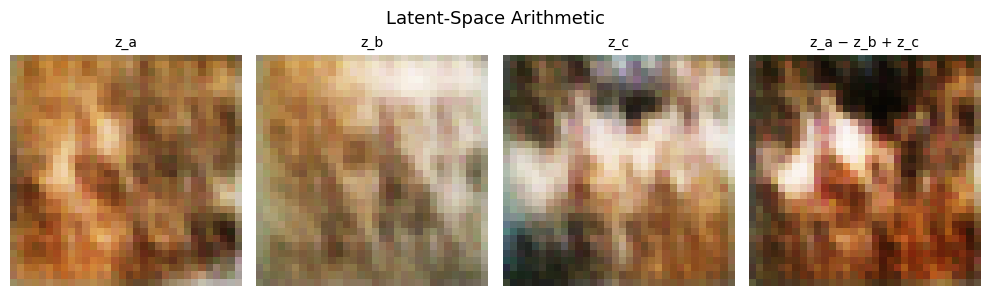

In [33]:
za = tf.random.normal([1, LATENT_DIM], seed=1)
zb = tf.random.normal([1, LATENT_DIM], seed=2)
zc = tf.random.normal([1, LATENT_DIM], seed=3)
zd = za - zb + zc  # arithmetic in latent space

labels = ["z_a", "z_b", "z_c", "z_a − z_b + z_c"]
vectors = [za, zb, zc, zd]

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for i, (lbl, zv) in enumerate(zip(labels, vectors)):
    img = generator(zv, training=False).numpy()[0] * 0.5 + 0.5
    axes[i].imshow(np.clip(img, 0, 1))
    axes[i].set_title(lbl, fontsize=10)
    axes[i].axis("off")
fig.suptitle("Latent-Space Arithmetic", fontsize=13)
plt.tight_layout()
plt.show()

## Summary

| Aspect | Detail |
|---|---|
| **Dataset** | CIFAR-10, single class — *dog* (5,000 images, 32×32 RGB) |
| **Generator** | Dense → Reshape(4×4×256) → 3× Conv2DTranspose (BN + ReLU) → tanh |
| **Discriminator** | 3× strided Conv2D (LeakyReLU + Dropout) → Flatten → Dense(1) |
| **Latent dim** | 128-dimensional Gaussian noise |
| **Training** | 80 epochs, batch size 128, Adam (lr=2e-4, β₁=0.5) |

